<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 40px; border-radius: 10px; margin-bottom: 20px;">
<h1 style="color: white; margin: 0; font-size: 2.5em;">Lecture 4: Analog Devices</h1>
<p style="color: #888; font-size: 1.2em; margin-top: 10px;">Part II: Devices & Circuits — SCE Futures</p>
</div>

## Contents

1. [SQUIDs — Superconducting Quantum Interference Devices](#1-squids)
2. [DC SQUID](#2-dc-squid)
3. [RF SQUID](#3-rf-squid)
4. [SQUID Applications](#4-squid-applications)
5. [Parametric Amplifiers](#5-parametric-amplifiers)
6. [Kinetic Inductance Devices](#6-kinetic-inductance)
7. [Superconducting Photon Detectors](#7-photon-detectors)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, Arc, FancyArrowPatch
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# Styling for all plots
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10

# Color palette
COLORS = {
    'primary': '#1a1a2e',
    'secondary': '#16213e',
    'accent1': '#e94560',
    'accent2': '#0f3460',
    'highlight': '#00d9ff',
    'success': '#00c853',
    'warning': '#ff9100'
}

# Physical constants
PHI_0 = 2.067833848e-15  # Wb (magnetic flux quantum)
h = 6.62607015e-34       # J·s (Planck constant)
e = 1.602176634e-19      # C (electron charge)
k_B = 1.380649e-23       # J/K (Boltzmann constant)

---
<a id="1-squids"></a>
# 1. SQUIDs — Superconducting Quantum Interference Devices
---

SQUIDs are the **most sensitive magnetic field detectors** ever developed, capable of measuring fields as small as **10⁻¹⁵ T/√Hz** — about 10 billion times weaker than Earth's magnetic field.

## Physical Principles

SQUIDs combine two fundamental quantum phenomena:

1. **Flux Quantization**: In a superconducting loop, the total magnetic flux is quantized:
   $$\Phi = n\Phi_0 \quad \text{where} \quad \Phi_0 = \frac{h}{2e} = 2.07 \times 10^{-15} \text{ Wb}$$

2. **Josephson Effect**: Supercurrent through a weak link depends on phase difference:
   $$I = I_c \sin(\phi)$$

## Why So Sensitive?

The flux quantum Φ₀ is extraordinarily small. A SQUID converts tiny magnetic flux changes into measurable voltage signals through quantum interference of Cooper pair wavefunctions.

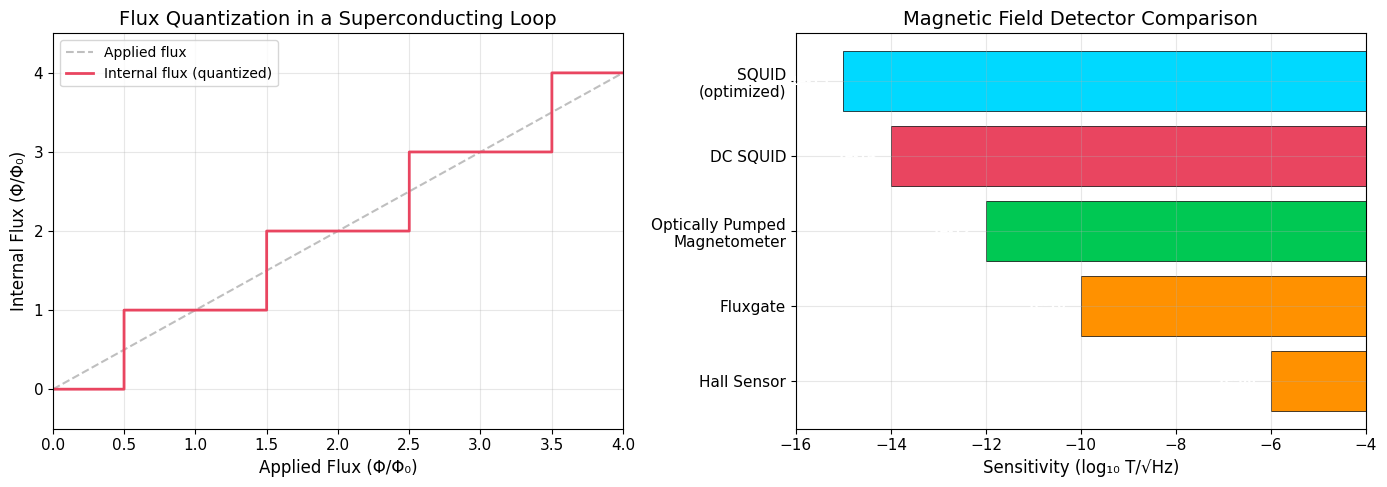

Flux quantum Φ₀ = 2.0678e-15 Wb
For a 1 mm² loop, Φ₀ corresponds to a field of 2.07e-09 T
SQUID can resolve ~10⁻⁶ Φ₀, enabling femtotesla sensitivity!


In [2]:
# Visualize flux quantization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Flux quantization concept
ax1 = axes[0]
phi_ext = np.linspace(0, 4, 1000)
phi_internal = np.round(phi_ext)  # Flux locks to nearest integer
screening_current = (phi_ext - phi_internal)  # Normalized

ax1.plot(phi_ext, phi_ext, '--', color='gray', alpha=0.5, label='Applied flux')
ax1.step(phi_ext, phi_internal, where='mid', linewidth=2, color=COLORS['accent1'], label='Internal flux (quantized)')
ax1.set_xlabel('Applied Flux (Φ/Φ₀)')
ax1.set_ylabel('Internal Flux (Φ/Φ₀)')
ax1.set_title('Flux Quantization in a Superconducting Loop')
ax1.legend()
ax1.set_xlim(0, 4)
ax1.set_ylim(-0.5, 4.5)

# Right: Sensitivity comparison
ax2 = axes[1]
detectors = ['Hall Sensor', 'Fluxgate', 'Optically Pumped\nMagnetometer', 'DC SQUID', 'SQUID\n(optimized)']
sensitivities = [1e-6, 1e-10, 1e-12, 1e-14, 1e-15]  # T/√Hz
colors = [COLORS['warning'], COLORS['warning'], COLORS['success'], COLORS['accent1'], COLORS['highlight']]

bars = ax2.barh(detectors, np.log10(sensitivities), color=colors, edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Sensitivity (log₁₀ T/√Hz)')
ax2.set_title('Magnetic Field Detector Comparison')
ax2.set_xlim(-16, -4)

# Add value labels
for bar, sens in zip(bars, sensitivities):
    ax2.text(bar.get_width() - 0.3, bar.get_y() + bar.get_height()/2, 
             f'{sens:.0e}', va='center', ha='right', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Flux quantum Φ₀ = {PHI_0:.4e} Wb")
print(f"For a 1 mm² loop, Φ₀ corresponds to a field of {PHI_0/1e-6:.2e} T")
print(f"SQUID can resolve ~10⁻⁶ Φ₀, enabling femtotesla sensitivity!")

---
<a id="2-dc-squid"></a>
# 2. DC SQUID
---

The **DC SQUID** consists of a superconducting loop interrupted by **two Josephson junctions**. It is the most sensitive and widely used SQUID configuration.

## Structure and Operation

**Key Components:**
- Superconducting loop (typically Nb) with inductance L
- Two Josephson junctions (typically Nb/Al-AlOx/Nb)
- Each junction has critical current I₀

**Operating Principle:**
When bias current I_b > 2I₀ is applied, the SQUID develops a voltage that depends on the magnetic flux through the loop.

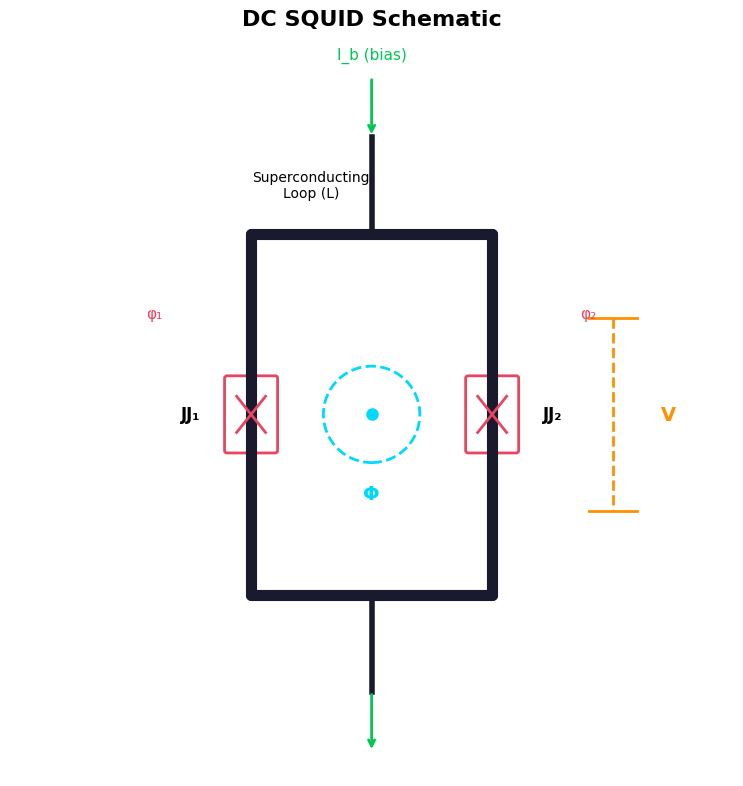

In [3]:
# DC SQUID schematic
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('DC SQUID Schematic', fontsize=16, fontweight='bold', pad=20)

# Draw superconducting loop
loop_color = COLORS['primary']
loop_width = 8

# Left side of loop
ax.plot([-1, -1], [-1.5, 1.5], color=loop_color, linewidth=loop_width, solid_capstyle='round')
# Right side of loop
ax.plot([1, 1], [-1.5, 1.5], color=loop_color, linewidth=loop_width, solid_capstyle='round')
# Top connection
ax.plot([-1, 1], [1.5, 1.5], color=loop_color, linewidth=loop_width, solid_capstyle='round')
# Bottom connection
ax.plot([-1, 1], [-1.5, -1.5], color=loop_color, linewidth=loop_width, solid_capstyle='round')

# Draw Josephson junctions (as X symbols)
jj_size = 0.25
for x_pos in [-1, 1]:
    y_pos = 0
    # Junction box
    rect = FancyBboxPatch((x_pos-0.2, y_pos-0.3), 0.4, 0.6, 
                          boxstyle="round,pad=0.02", facecolor='white', 
                          edgecolor=COLORS['accent1'], linewidth=2)
    ax.add_patch(rect)
    # X inside
    ax.plot([x_pos-0.12, x_pos+0.12], [y_pos-0.15, y_pos+0.15], color=COLORS['accent1'], linewidth=2)
    ax.plot([x_pos-0.12, x_pos+0.12], [y_pos+0.15, y_pos-0.15], color=COLORS['accent1'], linewidth=2)

# Bias current arrows
ax.annotate('', xy=(0, 2.3), xytext=(0, 2.8),
            arrowprops=dict(arrowstyle='->', color=COLORS['success'], lw=2))
ax.text(0, 2.95, 'I_b (bias)', ha='center', fontsize=11, color=COLORS['success'])

ax.annotate('', xy=(0, -2.8), xytext=(0, -2.3),
            arrowprops=dict(arrowstyle='->', color=COLORS['success'], lw=2))

# Current flow lines
ax.plot([0, 0], [1.5, 2.3], color=loop_color, linewidth=4)
ax.plot([0, 0], [-1.5, -2.3], color=loop_color, linewidth=4)

# Voltage measurement
ax.plot([1.8, 2.2], [0.8, 0.8], color=COLORS['warning'], linewidth=2)
ax.plot([1.8, 2.2], [-0.8, -0.8], color=COLORS['warning'], linewidth=2)
ax.plot([2, 2], [0.8, -0.8], color=COLORS['warning'], linewidth=2, linestyle='--')
ax.text(2.4, 0, 'V', fontsize=14, ha='left', va='center', color=COLORS['warning'], fontweight='bold')

# Magnetic flux symbol
circle = Circle((0, 0), 0.4, fill=False, color=COLORS['highlight'], linewidth=2, linestyle='--')
ax.add_patch(circle)
ax.plot([0], [0], 'o', markersize=8, color=COLORS['highlight'])
ax.text(0, -0.7, 'Φ', fontsize=14, ha='center', color=COLORS['highlight'], fontweight='bold')

# Labels
ax.text(-1.5, 0, 'JJ₁', fontsize=12, ha='center', va='center', fontweight='bold')
ax.text(1.5, 0, 'JJ₂', fontsize=12, ha='center', va='center', fontweight='bold')
ax.text(-0.5, 1.8, 'Superconducting\nLoop (L)', fontsize=10, ha='center')

# Phase labels
ax.text(-1.8, 0.8, 'φ₁', fontsize=11, ha='center', color=COLORS['accent1'])
ax.text(1.8, 0.8, 'φ₂', fontsize=11, ha='center', color=COLORS['accent1'])

plt.tight_layout()
plt.show()

## Critical Current Modulation

The total critical current of the DC SQUID oscillates with the applied magnetic flux:

$$I_c(\Phi) = 2I_0 \left| \cos\left(\frac{\pi \Phi}{\Phi_0}\right) \right|$$

where:
- I₀ = critical current of each junction
- Φ = magnetic flux through the loop
- Φ₀ = flux quantum (2.07 × 10⁻¹⁵ Wb)

**Physical Origin:**
The two junctions act like a "two-slit experiment" for Cooper pairs. The interference between supercurrents through each arm depends on the phase difference accumulated around the loop, which is proportional to the enclosed flux.

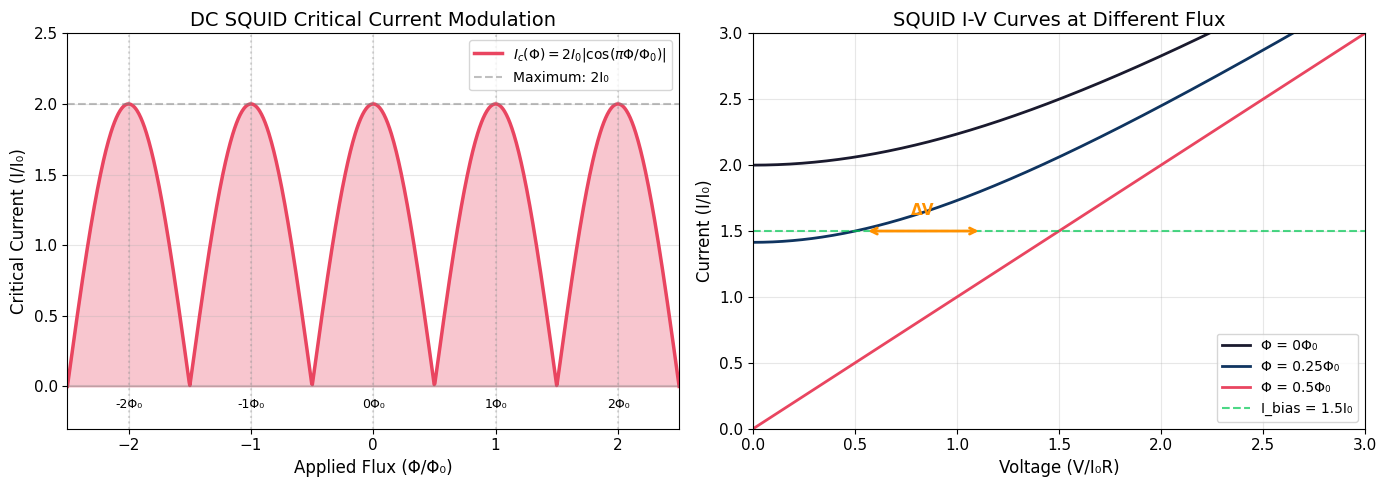

In [4]:
# Critical current modulation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Critical current vs flux
ax1 = axes[0]
phi = np.linspace(-2.5, 2.5, 1000)
I_0 = 1  # Normalized critical current per junction
I_c = 2 * I_0 * np.abs(np.cos(np.pi * phi))

ax1.fill_between(phi, 0, I_c, alpha=0.3, color=COLORS['accent1'])
ax1.plot(phi, I_c, linewidth=2.5, color=COLORS['accent1'], label=r'$I_c(\Phi) = 2I_0|\cos(\pi\Phi/\Phi_0)|$')
ax1.axhline(y=2*I_0, color='gray', linestyle='--', alpha=0.5, label='Maximum: 2I₀')
ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

# Mark key points
for n in range(-2, 3):
    ax1.axvline(x=n, color='gray', linestyle=':', alpha=0.3)
    ax1.text(n, -0.15, f'{n}Φ₀', ha='center', fontsize=9)

ax1.set_xlabel('Applied Flux (Φ/Φ₀)')
ax1.set_ylabel('Critical Current (I/I₀)')
ax1.set_title('DC SQUID Critical Current Modulation')
ax1.set_xlim(-2.5, 2.5)
ax1.set_ylim(-0.3, 2.5)
ax1.legend(loc='upper right')

# Right: I-V characteristics at different flux values
ax2 = axes[1]
V = np.linspace(0, 3, 500)

flux_values = [0, 0.25, 0.5]  # Φ/Φ₀
colors_iv = [COLORS['primary'], COLORS['accent2'], COLORS['accent1']]
R_n = 1  # Normal resistance

for phi_val, color in zip(flux_values, colors_iv):
    I_c_phi = 2 * I_0 * np.abs(np.cos(np.pi * phi_val))
    # Simplified I-V: I = sqrt(I_c² + (V/R_n)²)
    I = np.sqrt(I_c_phi**2 + (V/R_n)**2)
    ax2.plot(V, I, linewidth=2, color=color, label=f'Φ = {phi_val}Φ₀')

# Add bias point
I_bias = 1.5
ax2.axhline(y=I_bias, color=COLORS['success'], linestyle='--', alpha=0.7, label=f'I_bias = {I_bias}I₀')

# Show voltage modulation
ax2.annotate('', xy=(0.55, I_bias), xytext=(1.12, I_bias),
             arrowprops=dict(arrowstyle='<->', color=COLORS['warning'], lw=2))
ax2.text(0.83, I_bias+0.12, 'ΔV', fontsize=11, ha='center', color=COLORS['warning'], fontweight='bold')

ax2.set_xlabel('Voltage (V/I₀R)')
ax2.set_ylabel('Current (I/I₀)')
ax2.set_title('SQUID I-V Curves at Different Flux')
ax2.legend(loc='lower right')
ax2.set_xlim(0, 3)
ax2.set_ylim(0, 3)

plt.tight_layout()
plt.show()

## Flux-to-Voltage Transfer Function

When biased above the critical current, the SQUID voltage oscillates with applied flux:

$$V(\Phi) \approx V_0 + \frac{\partial V}{\partial \Phi} \cdot \delta\Phi$$

The **transfer coefficient** determines SQUID sensitivity:

$$\frac{\partial V}{\partial \Phi} \approx \frac{R}{L} \approx \frac{I_0 R_n}{\Phi_0} \approx 3.6 \text{ mV/}\Phi_0$$

where:
- R ≈ R_n/2 is the dynamic resistance
- L is the loop inductance
- Typical values: I₀ ≈ 10 μA, R_n ≈ 10 Ω

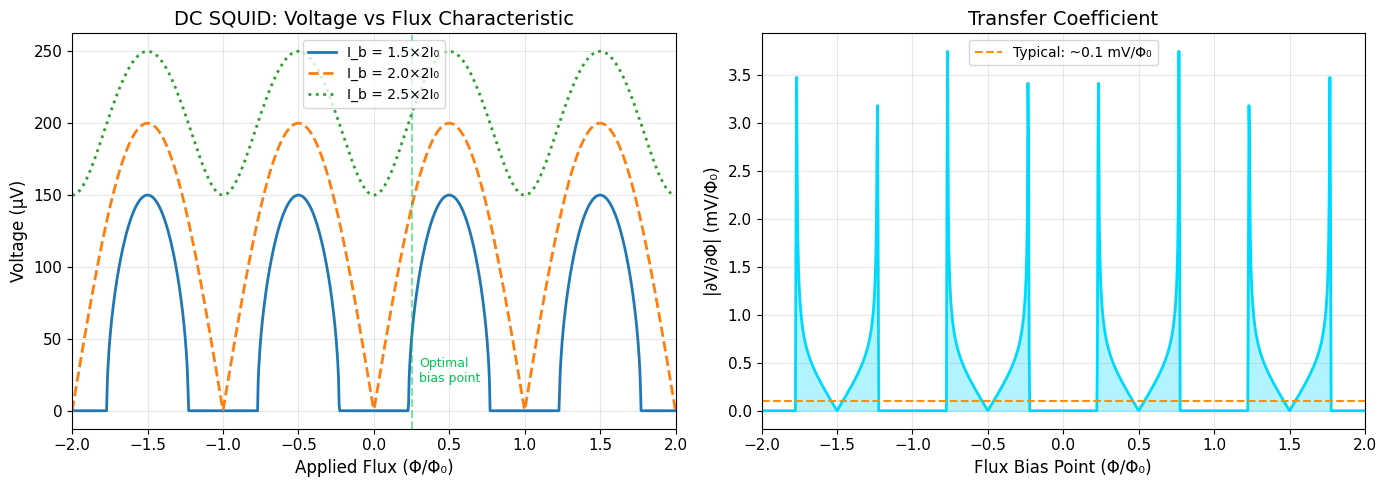

Typical DC SQUID Parameters:
  Junction critical current I₀ = 10 μA
  Junction normal resistance R_n = 10 Ω
  I₀R_n product = 100 μV
  Maximum transfer coefficient ≈ 0.1 mV/Φ₀
  For 1 fT field in 1 mm² loop: ΔΦ = 4.84e-07 Φ₀


In [5]:
# V-Φ characteristic
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: V-Φ curve
ax1 = axes[0]
phi = np.linspace(-2, 2, 1000)

# Simulated V-Φ at different bias currents
I_0 = 10e-6  # 10 μA
R_n = 10     # 10 Ω
I_c_R_n = I_0 * R_n  # 100 μV

def V_phi(phi, I_bias_ratio):
    """Approximate V-Φ characteristic"""
    I_c = 2 * np.abs(np.cos(np.pi * phi))
    # Above critical current, V depends on excess current
    V = np.sqrt(np.maximum(0, I_bias_ratio**2 - I_c**2))
    return V

for I_ratio, ls in [(1.5, '-'), (2.0, '--'), (2.5, ':')]:
    V = V_phi(phi, I_ratio) * I_c_R_n * 1e6  # Convert to μV
    ax1.plot(phi, V, linewidth=2, linestyle=ls, label=f'I_b = {I_ratio}×2I₀')

ax1.set_xlabel('Applied Flux (Φ/Φ₀)')
ax1.set_ylabel('Voltage (μV)')
ax1.set_title('DC SQUID: Voltage vs Flux Characteristic')
ax1.legend()
ax1.set_xlim(-2, 2)

# Mark optimal operating point
ax1.axvline(x=0.25, color=COLORS['success'], linestyle='--', alpha=0.5)
ax1.text(0.3, 20, 'Optimal\nbias point', fontsize=9, color=COLORS['success'])

# Right: Transfer function (dV/dΦ)
ax2 = axes[1]
phi_fine = np.linspace(-2, 2, 1000)
V_curve = V_phi(phi_fine, 1.5)
dV_dPhi = np.gradient(V_curve, phi_fine[1]-phi_fine[0])

# Scale to mV/Φ₀
transfer_coeff = dV_dPhi * I_c_R_n * 1e3  # mV/Φ₀

ax2.fill_between(phi_fine, 0, np.abs(transfer_coeff), alpha=0.3, color=COLORS['highlight'])
ax2.plot(phi_fine, np.abs(transfer_coeff), linewidth=2, color=COLORS['highlight'])
ax2.axhline(y=0.1, color=COLORS['warning'], linestyle='--', label='Typical: ~0.1 mV/Φ₀')

ax2.set_xlabel('Flux Bias Point (Φ/Φ₀)')
ax2.set_ylabel('|∂V/∂Φ| (mV/Φ₀)')
ax2.set_title('Transfer Coefficient')
ax2.legend()
ax2.set_xlim(-2, 2)

plt.tight_layout()
plt.show()

# Calculate typical values
print("Typical DC SQUID Parameters:")
print(f"  Junction critical current I₀ = 10 μA")
print(f"  Junction normal resistance R_n = 10 Ω")
print(f"  I₀R_n product = {I_0 * R_n * 1e6:.0f} μV")
print(f"  Maximum transfer coefficient ≈ {0.1:.1f} mV/Φ₀")
print(f"  For 1 fT field in 1 mm² loop: ΔΦ = {1e-15 * 1e-6 / PHI_0:.2e} Φ₀")

## Noise Sources in DC SQUIDs

The fundamental sensitivity limit is set by thermal noise in the junctions:

| Noise Source | Expression | Typical Value |
|--------------|------------|---------------|
| **Thermal (Johnson) noise** | $S_V = 4k_B T R$ | ~10⁻²² V²/Hz at 4K |
| **Flux noise (white)** | $S_\Phi^{1/2} \approx \sqrt{16 k_B T L^2/R}$ | ~1 μΦ₀/√Hz |
| **1/f noise** | Material-dependent | ~1-10 μΦ₀/√Hz at 1 Hz |
| **Quantum limit** | $S_\Phi \geq \hbar L$ | ~10⁻⁹ Φ₀/√Hz |

### Optimization Strategies

1. **Minimize loop inductance L**: Reduces flux noise, increases bandwidth
2. **Operate at low temperature**: Thermal noise ∝ T
3. **Use gradiometer design**: Cancels uniform background fields
4. **Optimize screening parameter β_L = 2LI₀/Φ₀ ≈ 1**

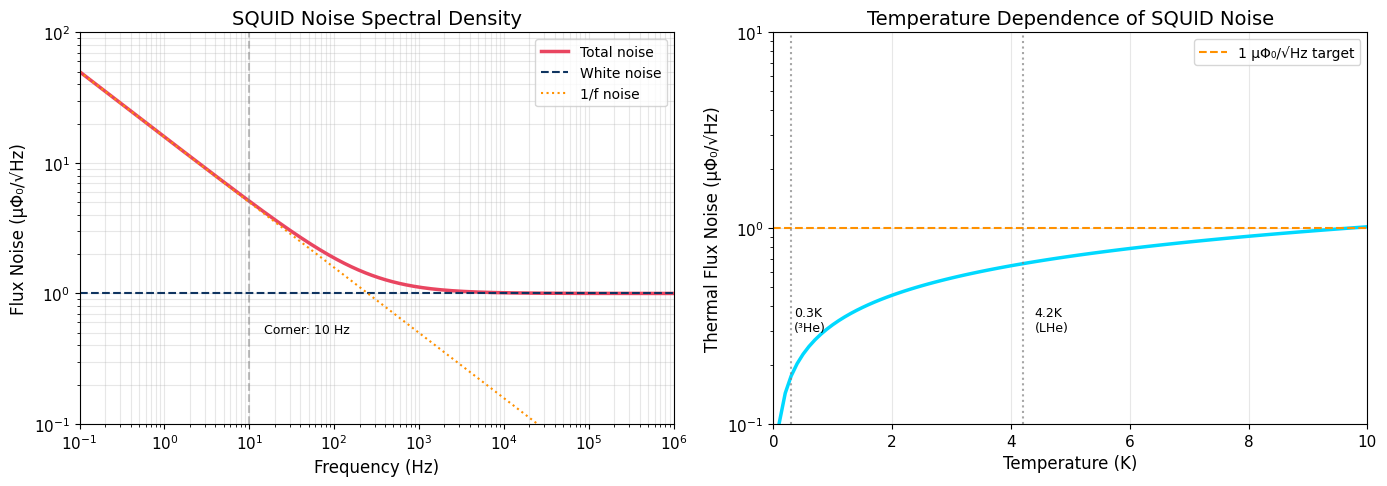

In [6]:
# SQUID noise analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Noise spectral density
ax1 = axes[0]
freq = np.logspace(-1, 6, 1000)  # 0.1 Hz to 1 MHz

# White noise floor
white_noise = 1e-6 * np.ones_like(freq)  # 1 μΦ₀/√Hz

# 1/f noise
f_corner = 10  # Hz
one_f_noise = 5e-6 * np.sqrt(f_corner / freq)

# Total noise
total_noise = np.sqrt(white_noise**2 + one_f_noise**2)

ax1.loglog(freq, total_noise * 1e6, linewidth=2.5, color=COLORS['accent1'], label='Total noise')
ax1.loglog(freq, white_noise * 1e6, '--', linewidth=1.5, color=COLORS['accent2'], label='White noise')
ax1.loglog(freq, one_f_noise * 1e6, ':', linewidth=1.5, color=COLORS['warning'], label='1/f noise')

ax1.axvline(x=f_corner, color='gray', linestyle='--', alpha=0.5)
ax1.text(f_corner*1.5, 0.5, f'Corner: {f_corner} Hz', fontsize=9)

ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Flux Noise (μΦ₀/√Hz)')
ax1.set_title('SQUID Noise Spectral Density')
ax1.legend(loc='upper right')
ax1.set_xlim(0.1, 1e6)
ax1.set_ylim(0.1, 100)
ax1.grid(True, which='both', alpha=0.3)

# Right: Noise vs temperature
ax2 = axes[1]
T = np.linspace(0.1, 10, 100)  # Temperature in K
L = 100e-12  # 100 pH loop inductance
R = 5  # 5 Ω

# Thermal flux noise
S_Phi_thermal = np.sqrt(16 * k_B * T * L**2 / R) / PHI_0  # In units of Φ₀/√Hz

ax2.semilogy(T, S_Phi_thermal * 1e6, linewidth=2.5, color=COLORS['highlight'])
ax2.axhline(y=1, color=COLORS['warning'], linestyle='--', label='1 μΦ₀/√Hz target')
ax2.axvline(x=4.2, color='gray', linestyle=':', alpha=0.7)
ax2.text(4.4, 0.3, '4.2K\n(LHe)', fontsize=9, ha='left')
ax2.axvline(x=0.3, color='gray', linestyle=':', alpha=0.7)
ax2.text(0.35, 0.3, '0.3K\n(³He)', fontsize=9, ha='left')

ax2.set_xlabel('Temperature (K)')
ax2.set_ylabel('Thermal Flux Noise (μΦ₀/√Hz)')
ax2.set_title('Temperature Dependence of SQUID Noise')
ax2.legend()
ax2.set_xlim(0, 10)
ax2.set_ylim(0.1, 10)

plt.tight_layout()
plt.show()

## Flux-Locked Loop (FLL) Operation

In practical applications, SQUIDs are operated in a **flux-locked loop** for:
- Linearized response over large dynamic range
- Stable operating point
- Reduced sensitivity to environmental drift

### FLL Principle

1. SQUID output voltage is amplified and integrated
2. Feedback current generates compensating flux
3. Net flux through SQUID is locked near optimal point
4. Feedback current is proportional to measured flux

$$V_{out} = M_{fb} \cdot I_{fb} = M_{fb} \cdot \frac{\Phi_{signal}}{M_{fb}} = \Phi_{signal}$$

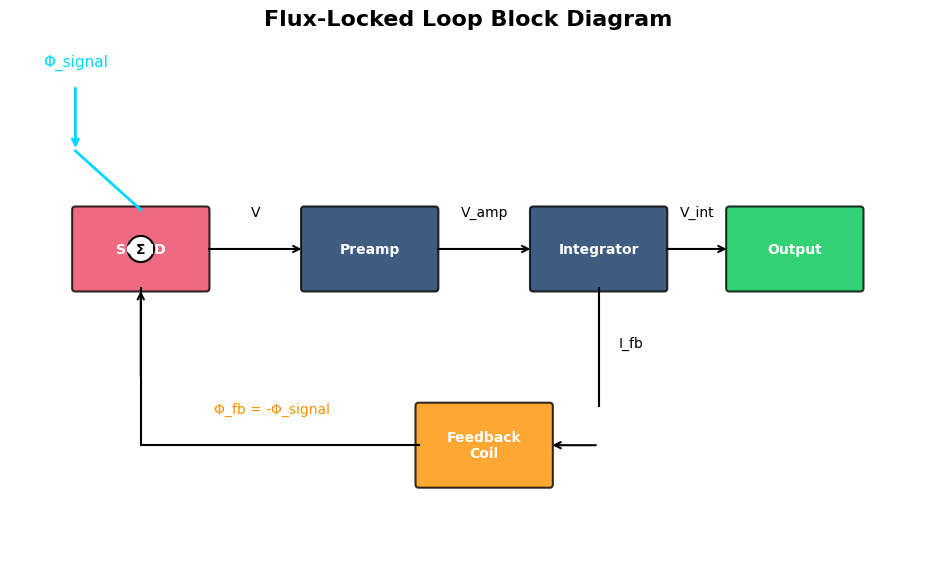

Flux-Locked Loop Advantages:
  • Linear response over many flux quanta
  • Dynamic range: >10⁶ (>120 dB)
  • Bandwidth: DC to ~MHz
  • Slew rate: ~10⁶ Φ₀/s typical


In [7]:
# Flux-locked loop block diagram
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
ax.set_xlim(-1, 13)
ax.set_ylim(-2, 6)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Flux-Locked Loop Block Diagram', fontsize=16, fontweight='bold', pad=20)

# Define block positions and sizes
block_height = 1.2
block_width = 2

def draw_block(ax, x, y, text, color=COLORS['primary']):
    rect = FancyBboxPatch((x, y-block_height/2), block_width, block_height,
                          boxstyle="round,pad=0.05", facecolor=color, 
                          edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.add_patch(rect)
    ax.text(x + block_width/2, y, text, ha='center', va='center', 
            fontsize=10, fontweight='bold', color='white')

# Draw blocks
draw_block(ax, 0, 3, 'SQUID', COLORS['accent1'])
draw_block(ax, 3.5, 3, 'Preamp', COLORS['accent2'])
draw_block(ax, 7, 3, 'Integrator', COLORS['accent2'])
draw_block(ax, 10, 3, 'Output', COLORS['success'])

# Feedback path
draw_block(ax, 5.25, 0, 'Feedback\nCoil', COLORS['warning'])

# Arrows - forward path
for x1, x2 in [(2, 3.5), (5.5, 7), (9, 10)]:
    ax.annotate('', xy=(x2, 3), xytext=(x1, 3),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Feedback arrows
ax.plot([8, 8], [3-block_height/2, 0.6], color='black', linewidth=1.5)
ax.annotate('', xy=(7.25, 0), xytext=(8, 0),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.plot([5.25, 1], [0, 0], color='black', linewidth=1.5)
ax.plot([1, 1], [0, 3-block_height/2], color='black', linewidth=1.5)
ax.annotate('', xy=(1, 2.4), xytext=(1, 1),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Input signal
ax.annotate('', xy=(0, 4.5), xytext=(0, 5.5),
            arrowprops=dict(arrowstyle='->', color=COLORS['highlight'], lw=2))
ax.text(0, 5.8, 'Φ_signal', ha='center', fontsize=11, color=COLORS['highlight'])
ax.plot([0, 1], [4.5, 3+block_height/2], color=COLORS['highlight'], linewidth=2)

# Labels
ax.text(2.75, 3.5, 'V', fontsize=10, ha='center')
ax.text(6.25, 3.5, 'V_amp', fontsize=10, ha='center')
ax.text(9.5, 3.5, 'V_int', fontsize=10, ha='center')
ax.text(8.5, 1.5, 'I_fb', fontsize=10, ha='center')
ax.text(3, 0.5, 'Φ_fb = -Φ_signal', fontsize=10, ha='center', color=COLORS['warning'])

# Add summing junction at SQUID
circle = Circle((1, 3), 0.2, fill=True, facecolor='white', edgecolor='black', linewidth=1.5)
ax.add_patch(circle)
ax.text(1, 3, 'Σ', ha='center', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("Flux-Locked Loop Advantages:")
print("  • Linear response over many flux quanta")
print("  • Dynamic range: >10⁶ (>120 dB)")
print("  • Bandwidth: DC to ~MHz")
print("  • Slew rate: ~10⁶ Φ₀/s typical")

---
<a id="3-rf-squid"></a>
# 3. RF SQUID
---

The **RF SQUID** uses a **single Josephson junction** in a superconducting loop, coupled to an RF tank circuit.

## Structure and Operation

| Feature | RF SQUID | DC SQUID |
|---------|----------|----------|
| Number of junctions | 1 | 2 |
| Readout method | RF tank circuit (~20-100 MHz) | DC voltage |
| Typical sensitivity | ~10⁻⁵ Φ₀/√Hz | ~10⁻⁶ Φ₀/√Hz |
| Bandwidth | Limited by RF frequency | DC to MHz |
| Historical use | Early MEG systems | Modern preference |

### Operating Principle

1. RF drive applied to tank circuit at resonance
2. SQUID loop inductively coupled to tank
3. Effective inductance of SQUID depends on flux state
4. Flux changes modulate RF amplitude/phase

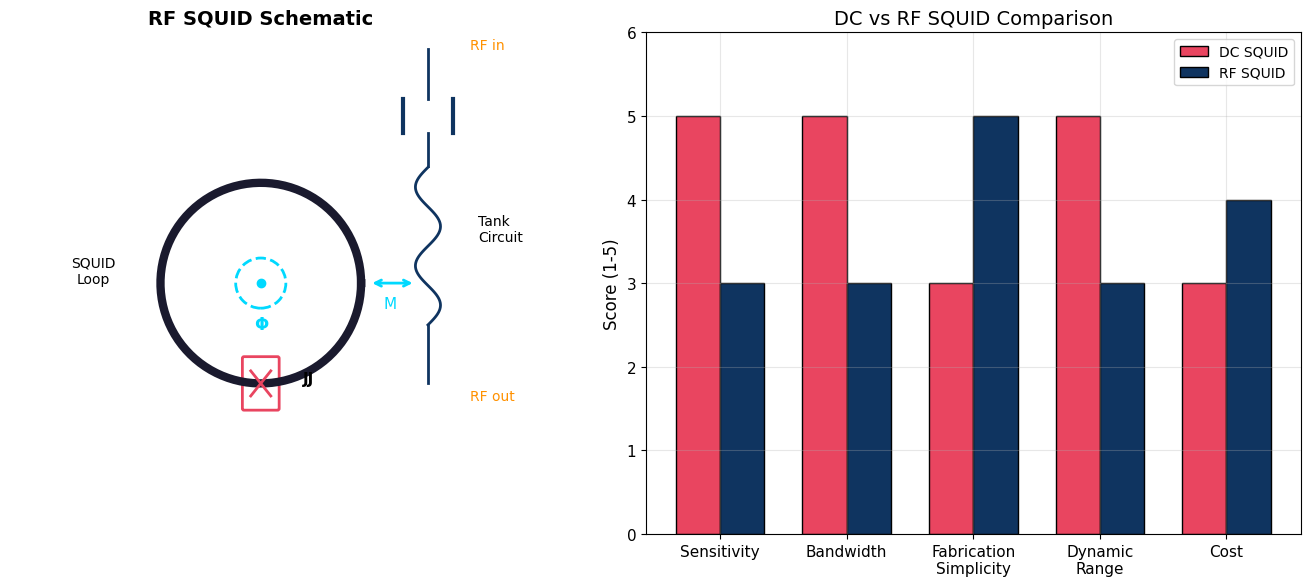

In [8]:
# RF SQUID schematic and comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: RF SQUID schematic
ax1 = axes[0]
ax1.set_xlim(-3, 3)
ax1.set_ylim(-3, 3)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('RF SQUID Schematic', fontsize=14, fontweight='bold')

# SQUID loop
loop_color = COLORS['primary']
theta = np.linspace(0, 2*np.pi, 100)
r = 1.2
x_loop = r * np.cos(theta)
y_loop = r * np.sin(theta)
ax1.plot(x_loop, y_loop, color=loop_color, linewidth=6)

# Single junction at bottom
rect = FancyBboxPatch((-0.2, -1.5), 0.4, 0.6, 
                      boxstyle="round,pad=0.02", facecolor='white', 
                      edgecolor=COLORS['accent1'], linewidth=2)
ax1.add_patch(rect)
ax1.plot([-0.12, 0.12], [-1.35, -1.05], color=COLORS['accent1'], linewidth=2)
ax1.plot([-0.12, 0.12], [-1.05, -1.35], color=COLORS['accent1'], linewidth=2)
ax1.text(0.5, -1.2, 'JJ', fontsize=11, fontweight='bold')

# Tank circuit (LC resonator)
# Inductor (coil symbol)
t = np.linspace(0, 4*np.pi, 100)
x_coil = 2 + 0.15 * np.sin(t)
y_coil = -0.5 + t * 0.15
ax1.plot(x_coil, y_coil, color=COLORS['accent2'], linewidth=2)

# Capacitor
ax1.plot([1.7, 1.7], [1.8, 2.2], color=COLORS['accent2'], linewidth=3)
ax1.plot([2.3, 2.3], [1.8, 2.2], color=COLORS['accent2'], linewidth=3)

# Connections
ax1.plot([2, 2], [1.4, 1.8], color=COLORS['accent2'], linewidth=2)
ax1.plot([2, 2], [2.2, 2.8], color=COLORS['accent2'], linewidth=2)
ax1.plot([2, 2], [-1.2, -0.5], color=COLORS['accent2'], linewidth=2)

# RF drive
ax1.text(2.5, 2.8, 'RF in', fontsize=10, color=COLORS['warning'])
ax1.text(2.5, -1.4, 'RF out', fontsize=10, color=COLORS['warning'])

# Mutual inductance coupling
ax1.annotate('', xy=(1.3, 0), xytext=(1.85, 0),
             arrowprops=dict(arrowstyle='<->', color=COLORS['highlight'], lw=2))
ax1.text(1.55, -0.3, 'M', fontsize=11, ha='center', color=COLORS['highlight'])

# Flux
circle = Circle((0, 0), 0.3, fill=False, color=COLORS['highlight'], linewidth=2, linestyle='--')
ax1.add_patch(circle)
ax1.plot([0], [0], 'o', markersize=6, color=COLORS['highlight'])
ax1.text(0, -0.55, 'Φ', fontsize=12, ha='center', color=COLORS['highlight'], fontweight='bold')

# Labels
ax1.text(-2, 0, 'SQUID\nLoop', fontsize=10, ha='center')
ax1.text(2.6, 0.5, 'Tank\nCircuit', fontsize=10, ha='left')

# Right: Performance comparison
ax2 = axes[1]
categories = ['Sensitivity', 'Bandwidth', 'Fabrication\nSimplicity', 'Dynamic\nRange', 'Cost']
dc_scores = [5, 5, 3, 5, 3]
rf_scores = [3, 3, 5, 3, 4]

x = np.arange(len(categories))
width = 0.35

bars1 = ax2.bar(x - width/2, dc_scores, width, label='DC SQUID', color=COLORS['accent1'], edgecolor='black')
bars2 = ax2.bar(x + width/2, rf_scores, width, label='RF SQUID', color=COLORS['accent2'], edgecolor='black')

ax2.set_ylabel('Score (1-5)')
ax2.set_title('DC vs RF SQUID Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.legend()
ax2.set_ylim(0, 6)

plt.tight_layout()
plt.show()

---
<a id="4-squid-applications"></a>
# 4. SQUID Applications
---

SQUIDs find applications wherever extreme magnetic sensitivity is required.

## Application Summary

| Application | Field Levels | Key Requirements |
|-------------|--------------|------------------|
| **MEG** (Magnetoencephalography) | 10-1000 fT | 100+ channel arrays, gradiometers |
| **MCG** (Magnetocardiography) | 1-100 pT | Multi-channel, real-time |
| **Geophysical Surveying** | 0.1-100 nT | Rugged, portable, gradiometer |
| **Materials Characterization** | Variable | VSM, susceptometry |
| **Non-Destructive Testing** | 1-100 pT | Eddy current detection |
| **Fundamental Physics** | 10⁻¹⁸ T | Gravity wave detectors |

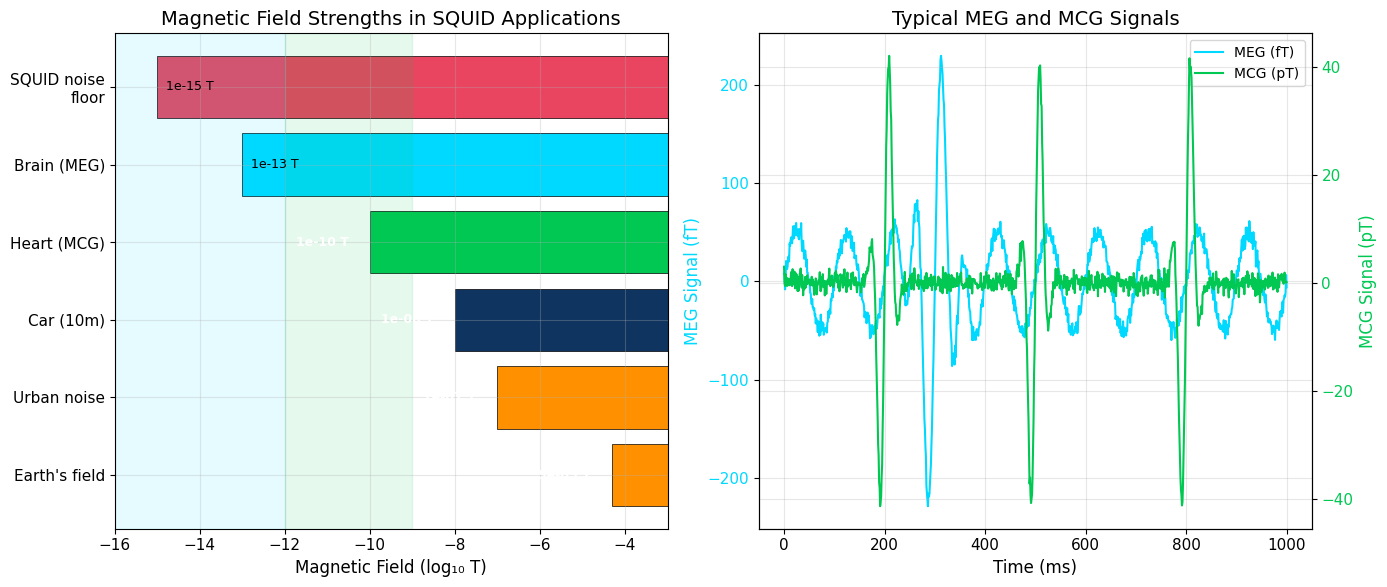

In [9]:
# SQUID application visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Field strength comparison
ax1 = axes[0]
sources = ['Earth\'s field', 'Urban noise', 'Car (10m)', 'Heart (MCG)', 'Brain (MEG)', 'SQUID noise\nfloor']
fields = [5e-5, 1e-7, 1e-8, 1e-10, 1e-13, 1e-15]  # Tesla
colors = [COLORS['warning'], COLORS['warning'], COLORS['accent2'], 
          COLORS['success'], COLORS['highlight'], COLORS['accent1']]

y_pos = np.arange(len(sources))
bars = ax1.barh(y_pos, np.log10(fields), color=colors, edgecolor='black', linewidth=0.5)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(sources)
ax1.set_xlabel('Magnetic Field (log₁₀ T)')
ax1.set_title('Magnetic Field Strengths in SQUID Applications')
ax1.set_xlim(-16, -3)

# Add value labels
for bar, field in zip(bars, fields):
    if field >= 1e-10:
        ax1.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height()/2, 
                 f'{field:.0e} T', va='center', ha='right', fontsize=9, color='white', fontweight='bold')
    else:
        ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, 
                 f'{field:.0e} T', va='center', ha='left', fontsize=9)

# Shaded regions
ax1.axvspan(-16, -12, alpha=0.1, color=COLORS['highlight'], label='MEG range')
ax1.axvspan(-12, -9, alpha=0.1, color=COLORS['success'], label='MCG range')

# Right: MEG/MCG signal characteristics
ax2 = axes[1]
t = np.linspace(0, 1, 1000)  # 1 second

# Simulated MEG signal (alpha rhythm ~10 Hz + evoked response)
alpha = 50e-15 * np.sin(2*np.pi*10*t)  # Alpha rhythm
evoked = 200e-15 * np.exp(-((t-0.3)/0.05)**2) * np.sin(2*np.pi*20*(t-0.3))  # Evoked
meg_signal = alpha + evoked + 5e-15 * np.random.randn(len(t))  # Add noise

# Simulated MCG signal (heart rhythm)
def qrs_complex(t, t0):
    """Simple QRS complex model"""
    return 50e-12 * np.exp(-((t-t0)/0.02)**2) * np.sin(2*np.pi*25*(t-t0))

mcg_signal = np.zeros_like(t)
for t0 in [0.2, 0.5, 0.8]:  # Heartbeats
    mcg_signal += qrs_complex(t, t0)
mcg_signal += 1e-12 * np.random.randn(len(t))

# Plot
ax2_twin = ax2.twinx()

line1, = ax2.plot(t*1000, meg_signal*1e15, color=COLORS['highlight'], linewidth=1.5, label='MEG (fT)')
line2, = ax2_twin.plot(t*1000, mcg_signal*1e12, color=COLORS['success'], linewidth=1.5, label='MCG (pT)')

ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('MEG Signal (fT)', color=COLORS['highlight'])
ax2_twin.set_ylabel('MCG Signal (pT)', color=COLORS['success'])
ax2.set_title('Typical MEG and MCG Signals')

ax2.tick_params(axis='y', labelcolor=COLORS['highlight'])
ax2_twin.tick_params(axis='y', labelcolor=COLORS['success'])

# Combined legend
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.show()

## Magnetoencephalography (MEG)

MEG measures the magnetic fields produced by neural currents in the brain:

- **Signal levels**: 10-1000 fT (femtotesla)
- **Bandwidth**: DC to ~1 kHz
- **Channel count**: 100-300+ SQUIDs in helmet array
- **Shielding**: Magnetically shielded room (MSR) required

### Clinical Applications
- Pre-surgical mapping of epileptic foci
- Functional brain mapping
- Cognitive neuroscience research

## Magnetocardiography (MCG)

MCG detects the heart's magnetic field, complementing ECG:

- **Signal levels**: 1-100 pT (picotesla)
- **Advantages over ECG**: Non-contact, better spatial resolution
- **Applications**: Fetal heart monitoring, arrhythmia detection

## Geophysical Applications

SQUIDs enable detection of subsurface conductivity variations:

- **Mineral exploration**: Detecting ore bodies
- **Groundwater mapping**: Conductivity changes
- **Archaeological surveys**: Buried structures
- **UXO detection**: Unexploded ordnance

---
<a id="5-parametric-amplifiers"></a>
# 5. Parametric Amplifiers
---

Superconducting parametric amplifiers achieve **quantum-limited noise performance**, essential for qubit readout.

## Josephson Parametric Amplifier (JPA)

The JPA exploits the **nonlinear inductance** of a Josephson junction:

$$L_J(I) = \frac{\Phi_0}{2\pi I_c \cos(\phi)} = \frac{L_{J0}}{\cos(\phi)}$$

### Operating Principle

1. **Pump tone** at frequency ω_p modulates junction inductance
2. **Signal** at ω_s experiences parametric gain
3. **Idler** generated at ω_i = ω_p - ω_s (or 2ω_p - ω_s)
4. Energy transfers from pump to signal/idler

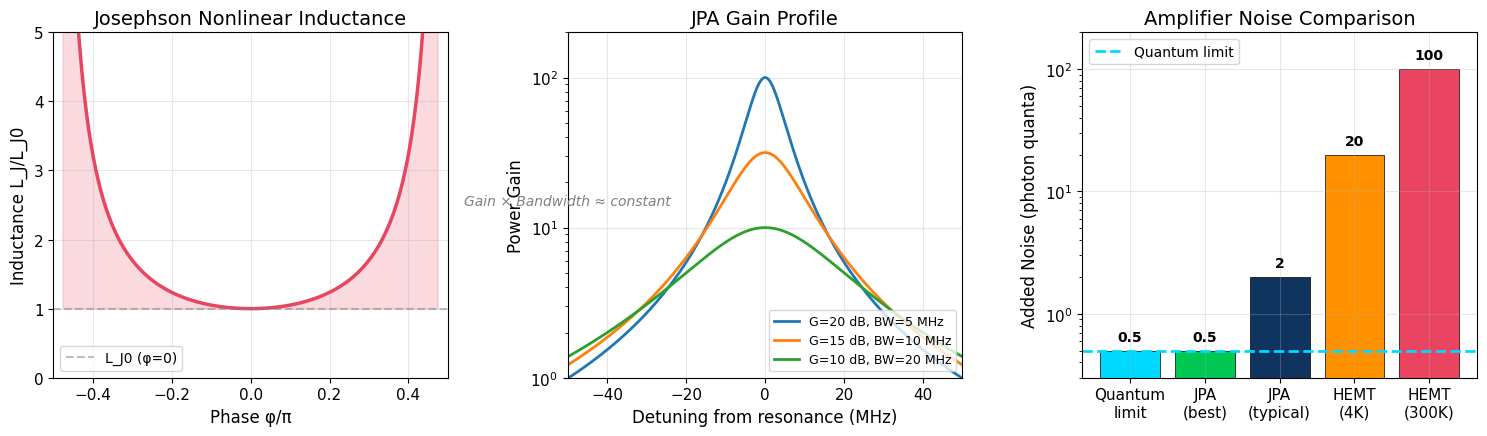

In [10]:
# JPA nonlinear inductance and gain
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Left: Nonlinear inductance
ax1 = axes[0]
phi = np.linspace(-0.95*np.pi/2, 0.95*np.pi/2, 500)
L_J = 1 / np.cos(phi)  # Normalized inductance

ax1.plot(phi/np.pi, L_J, linewidth=2.5, color=COLORS['accent1'])
ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='L_J0 (φ=0)')
ax1.fill_between(phi/np.pi, 1, L_J, alpha=0.2, color=COLORS['accent1'])

ax1.set_xlabel('Phase φ/π')
ax1.set_ylabel('Inductance L_J/L_J0')
ax1.set_title('Josephson Nonlinear Inductance')
ax1.set_xlim(-0.5, 0.5)
ax1.set_ylim(0, 5)
ax1.legend()

# Middle: Parametric gain
ax2 = axes[1]
delta_f = np.linspace(-50, 50, 1000)  # MHz detuning

# Different pump powers (bandwidth-gain tradeoff)
def lorentzian_gain(delta_f, gain_max, bandwidth):
    return gain_max / (1 + (delta_f/bandwidth)**2)

for G_max, BW, label in [(20, 5, 'G=20 dB, BW=5 MHz'), 
                          (15, 10, 'G=15 dB, BW=10 MHz'),
                          (10, 20, 'G=10 dB, BW=20 MHz')]:
    G = lorentzian_gain(delta_f, 10**(G_max/10), BW)
    ax2.semilogy(delta_f, G, linewidth=2, label=label)

ax2.set_xlabel('Detuning from resonance (MHz)')
ax2.set_ylabel('Power Gain')
ax2.set_title('JPA Gain Profile')
ax2.legend(loc='lower right', fontsize=9)
ax2.set_xlim(-50, 50)
ax2.set_ylim(1, 200)

# Add annotation about bandwidth-gain tradeoff
ax2.text(0, 0.5, 'Gain × Bandwidth ≈ constant', transform=ax2.transAxes,
         ha='center', fontsize=10, style='italic', color='gray')

# Right: Noise performance comparison
ax3 = axes[2]
amplifiers = ['Quantum\nlimit', 'JPA\n(best)', 'JPA\n(typical)', 'HEMT\n(4K)', 'HEMT\n(300K)']
noise_quanta = [0.5, 0.5, 2, 20, 100]  # Added noise in photon quanta
colors = [COLORS['highlight'], COLORS['success'], COLORS['accent2'], COLORS['warning'], COLORS['accent1']]

bars = ax3.bar(amplifiers, noise_quanta, color=colors, edgecolor='black', linewidth=0.5)
ax3.set_ylabel('Added Noise (photon quanta)')
ax3.set_title('Amplifier Noise Comparison')
ax3.set_yscale('log')
ax3.set_ylim(0.3, 200)

# Quantum limit line
ax3.axhline(y=0.5, color=COLORS['highlight'], linestyle='--', linewidth=2, label='Quantum limit')
ax3.legend()

# Add value labels
for bar, noise in zip(bars, noise_quanta):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.2, 
             f'{noise}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Quantum-Limited Noise

The **standard quantum limit** for phase-preserving amplification:

$$T_N \geq \frac{\hbar \omega}{2k_B} \quad \text{or equivalently} \quad n_{added} \geq \frac{1}{2}$$

This corresponds to adding at least **half a photon of noise** at the signal frequency.

| Parameter | JPA | HEMT (4K) |
|-----------|-----|----------|
| Noise temperature | ~50 mK | ~2-5 K |
| Added noise | 0.5-2 quanta | ~20 quanta |
| Gain | 15-25 dB | 30-40 dB |
| Bandwidth | 5-50 MHz | GHz |
| Saturation power | ~-100 dBm | ~-30 dBm |

## Traveling Wave Parametric Amplifier (TWPA)

TWPAs overcome the bandwidth limitation of JPAs:

- **Structure**: Transmission line with embedded Josephson junctions or kinetic inductance
- **Bandwidth**: Several GHz (vs. ~10 MHz for JPA)
- **Gain**: 15-20 dB
- **Applications**: Multi-qubit readout, frequency multiplexing

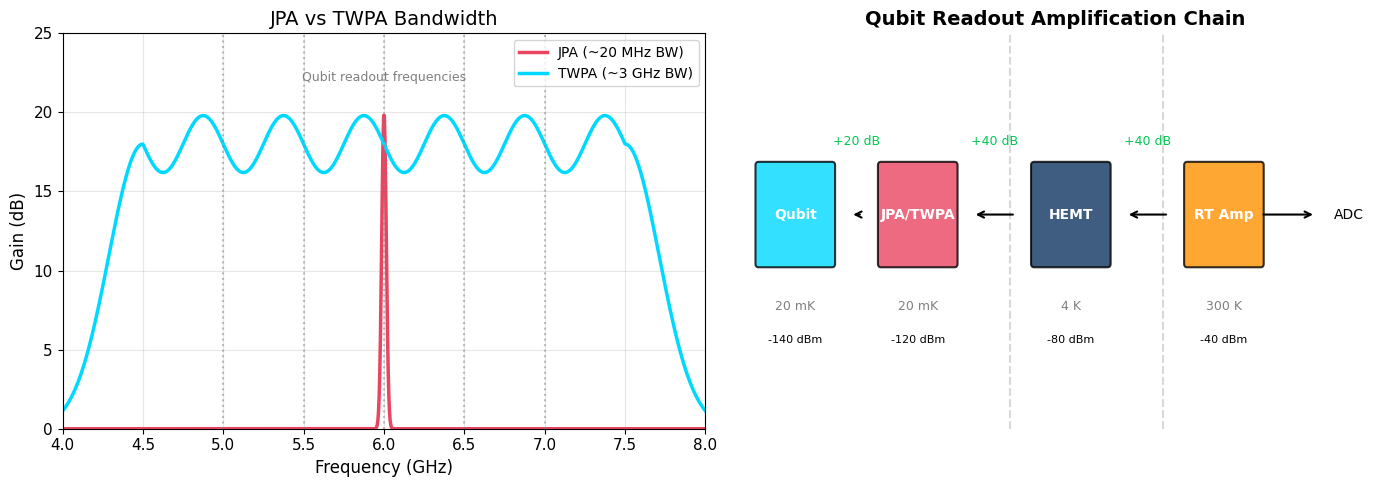

Parametric Amplifier Key Points:
  • JPA achieves quantum-limited noise (~0.5 photons added)
  • TWPA extends bandwidth to several GHz
  • Essential for high-fidelity qubit readout (>99%)
  • Enables single-shot qubit measurement


In [11]:
# TWPA comparison and qubit readout chain
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: JPA vs TWPA bandwidth
ax1 = axes[0]
f = np.linspace(4, 8, 1000)  # GHz

# JPA: narrow band
f_center = 6
jpa_gain = 20 * np.exp(-((f - f_center)/0.02)**2)  # ~20 MHz bandwidth

# TWPA: broadband
twpa_gain = 18 * np.ones_like(f)
twpa_gain = twpa_gain * (1 - 0.1*np.sin(2*np.pi*(f-4)/0.5))  # Ripple
twpa_gain[f < 4.5] = 18 * np.exp(-((f[f < 4.5] - 4.5)/0.3)**2)
twpa_gain[f > 7.5] = 18 * np.exp(-((f[f > 7.5] - 7.5)/0.3)**2)

ax1.plot(f, jpa_gain, linewidth=2.5, color=COLORS['accent1'], label='JPA (~20 MHz BW)')
ax1.plot(f, twpa_gain, linewidth=2.5, color=COLORS['highlight'], label='TWPA (~3 GHz BW)')

ax1.set_xlabel('Frequency (GHz)')
ax1.set_ylabel('Gain (dB)')
ax1.set_title('JPA vs TWPA Bandwidth')
ax1.legend()
ax1.set_xlim(4, 8)
ax1.set_ylim(0, 25)

# Show qubit readout frequencies
for fq in [5.0, 5.5, 6.0, 6.5, 7.0]:
    ax1.axvline(x=fq, color='gray', linestyle=':', alpha=0.5)
ax1.text(6, 22, 'Qubit readout frequencies', ha='center', fontsize=9, color='gray')

# Right: Amplification chain for qubit readout
ax2 = axes[1]
ax2.set_xlim(-0.5, 10)
ax2.set_ylim(-1, 5)
ax2.axis('off')
ax2.set_title('Qubit Readout Amplification Chain', fontsize=14, fontweight='bold')

# Define stages
stages = [
    ('Qubit', 0.5, '20 mK', COLORS['highlight']),
    ('JPA/TWPA', 2.5, '20 mK', COLORS['accent1']),
    ('HEMT', 5, '4 K', COLORS['accent2']),
    ('RT Amp', 7.5, '300 K', COLORS['warning'])
]

# Signal levels
signal_levels = [-140, -120, -80, -40]  # dBm

for i, (name, x, temp, color) in enumerate(stages):
    # Stage box
    rect = FancyBboxPatch((x-0.6, 1.5), 1.2, 1.5,
                          boxstyle="round,pad=0.05", facecolor=color, 
                          edgecolor='black', linewidth=1.5, alpha=0.8)
    ax2.add_patch(rect)
    ax2.text(x, 2.25, name, ha='center', va='center', fontsize=10, 
             fontweight='bold', color='white')
    ax2.text(x, 0.8, temp, ha='center', fontsize=9, color='gray')
    ax2.text(x, 0.3, f'{signal_levels[i]} dBm', ha='center', fontsize=8)
    
    # Arrow to next
    if i < len(stages) - 1:
        ax2.annotate('', xy=(x+0.9, 2.25), xytext=(stages[i+1][1]-0.9, 2.25),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1.5,
                                    connectionstyle='arc3,rad=0'))

# Temperature stages
ax2.axvline(x=4, color='gray', linestyle='--', alpha=0.3)
ax2.axvline(x=6.5, color='gray', linestyle='--', alpha=0.3)

# Add gain labels
gains = ['+20 dB', '+40 dB', '+40 dB']
for i, gain in enumerate(gains):
    x_mid = (stages[i][1] + stages[i+1][1]) / 2
    ax2.text(x_mid, 3.3, gain, ha='center', fontsize=9, color=COLORS['success'])

# Output
ax2.annotate('', xy=(9, 2.25), xytext=(8.1, 2.25),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax2.text(9.3, 2.25, 'ADC', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Parametric Amplifier Key Points:")
print("  • JPA achieves quantum-limited noise (~0.5 photons added)")
print("  • TWPA extends bandwidth to several GHz")
print("  • Essential for high-fidelity qubit readout (>99%)")
print("  • Enables single-shot qubit measurement")

---
<a id="6-kinetic-inductance"></a>
# 6. Kinetic Inductance Devices
---

**Kinetic inductance** arises from the inertia of Cooper pairs, providing a purely electronic inductance without magnetic fields.

## Physical Origin

When Cooper pairs accelerate, they store kinetic energy:

$$E_k = \frac{1}{2} n_s (2m_e) v_s^2 \cdot V_{wire} = \frac{1}{2} L_k I^2$$

This leads to the kinetic inductance:

$$L_k = \frac{m_e}{n_s e^2} \cdot \frac{l}{A} = \frac{\mu_0 \lambda^2 l}{A}$$

where:
- n_s = superfluid density
- λ = London penetration depth
- l = wire length
- A = cross-sectional area

### Key Insight: $L_k \propto \frac{1}{n_s \cdot A}$

Kinetic inductance becomes large when:
1. **Thin films**: Small cross-section A
2. **Materials with low n_s**: Large penetration depth λ

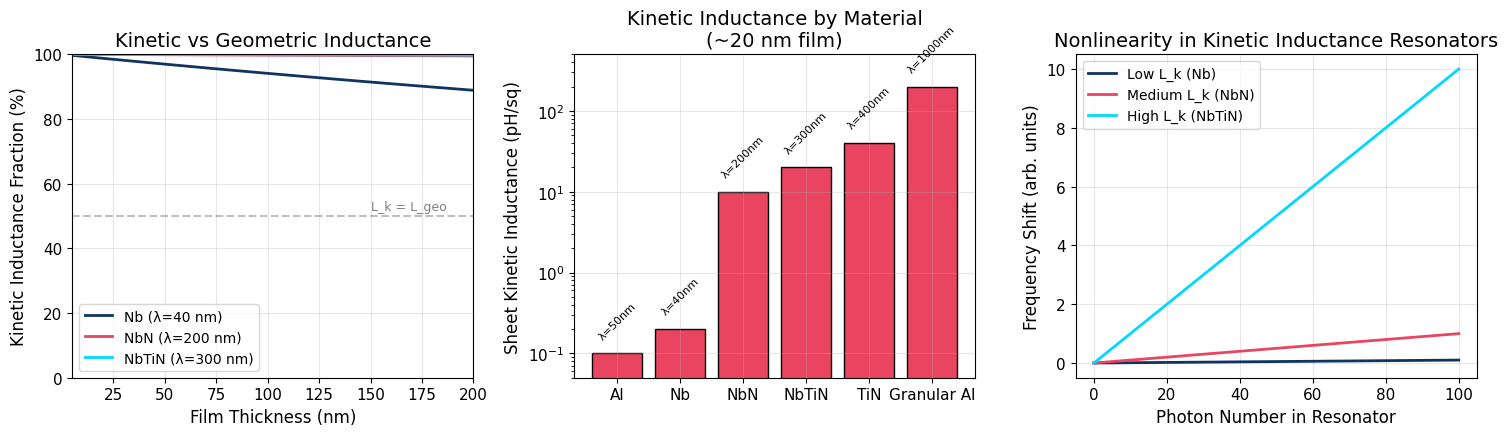

In [12]:
# Kinetic inductance visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Left: Kinetic vs geometric inductance
ax1 = axes[0]

# For a thin film strip: L_geo ≈ μ₀ l / w, L_k = μ₀ λ² l / (w × t)
thickness = np.linspace(5, 200, 100)  # nm
width = 1000  # nm (1 μm)
length = 1000e3  # nm (1 mm)

mu_0 = 4 * np.pi * 1e-7  # H/m

# Different materials
materials = [
    ('Nb', 90, COLORS['accent2']),      # λ = 40 nm
    ('NbN', 200, COLORS['accent1']),     # λ = 200 nm
    ('NbTiN', 300, COLORS['highlight'])  # λ = 300 nm
]

# Geometric inductance (independent of material)
L_geo = mu_0 * length / width * 1e-9  # Convert nm to m

for name, lam, color in materials:
    L_k = mu_0 * (lam * 1e-9)**2 * (length * 1e-9) / ((width * 1e-9) * (thickness * 1e-9))
    L_total = L_geo + L_k
    kinetic_fraction = L_k / L_total * 100
    ax1.plot(thickness, kinetic_fraction, linewidth=2, color=color, label=f'{name} (λ={lam} nm)')

ax1.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax1.text(150, 52, 'L_k = L_geo', fontsize=9, color='gray')

ax1.set_xlabel('Film Thickness (nm)')
ax1.set_ylabel('Kinetic Inductance Fraction (%)')
ax1.set_title('Kinetic vs Geometric Inductance')
ax1.legend()
ax1.set_xlim(5, 200)
ax1.set_ylim(0, 100)

# Middle: Sheet inductance values
ax2 = axes[1]
materials_data = {
    'Material': ['Al', 'Nb', 'NbN', 'NbTiN', 'TiN', 'Granular Al'],
    'λ (nm)': [50, 90, 200, 300, 400, 1000],
    'L_s (pH/sq)': [0.1, 0.2, 10, 20, 40, 200]  # Sheet inductance for ~20nm films
}

x = np.arange(len(materials_data['Material']))
bars = ax2.bar(x, materials_data['L_s (pH/sq)'], color=COLORS['accent1'], edgecolor='black')

ax2.set_xticks(x)
ax2.set_xticklabels(materials_data['Material'])
ax2.set_ylabel('Sheet Kinetic Inductance (pH/sq)')
ax2.set_title('Kinetic Inductance by Material\n(~20 nm film)')
ax2.set_yscale('log')
ax2.set_ylim(0.05, 500)

# Add λ values as text
for i, lam in enumerate(materials_data['λ (nm)']):
    ax2.text(i, materials_data['L_s (pH/sq)'][i] * 1.5, f'λ={lam}nm', 
             ha='center', fontsize=8, rotation=45)

# Right: Why high kinetic inductance matters
ax3 = axes[2]

# Resonator frequency shift with photon number
n_photons = np.linspace(0, 100, 100)

# Kerr nonlinearity: δf ∝ L_k × n
for L_k_rel, label, color in [(1, 'Low L_k (Nb)', COLORS['accent2']),
                                (10, 'Medium L_k (NbN)', COLORS['accent1']),
                                (100, 'High L_k (NbTiN)', COLORS['highlight'])]:
    delta_f = L_k_rel * n_photons * 0.001  # Normalized frequency shift
    ax3.plot(n_photons, delta_f, linewidth=2, color=color, label=label)

ax3.set_xlabel('Photon Number in Resonator')
ax3.set_ylabel('Frequency Shift (arb. units)')
ax3.set_title('Nonlinearity in Kinetic Inductance Resonators')
ax3.legend(loc='upper left')

plt.tight_layout()
plt.show()

## Why NbN and NbTiN?

| Material | T_c (K) | λ (nm) | L_k/L_geo | Key Properties |
|----------|---------|--------|-----------|----------------|
| **Nb** | 9.2 | 90 | Low | Standard, well-characterized |
| **NbN** | 16 | 200 | High | Higher T_c, good for SNSPDs |
| **NbTiN** | 15 | 300 | Very high | Tunable, low loss |
| **TiN** | 4.5 | 400 | Very high | CMOS compatible |
| **Granular Al** | 2 | 500-2000 | Extreme | Highest kinetic inductance |

## Kinetic Inductance Detectors (KIDs/MKIDs)

**Microwave Kinetic Inductance Detectors** exploit the change in kinetic inductance when Cooper pairs are broken:

1. **Photon absorption** breaks Cooper pairs into quasiparticles
2. **Superfluid density n_s decreases** → kinetic inductance increases
3. **Resonator frequency shifts** (measurable change)

### Advantages
- Natural frequency multiplexing (thousands of pixels on one feedline)
- Simpler readout than TES
- Good for large-format arrays (astronomy)

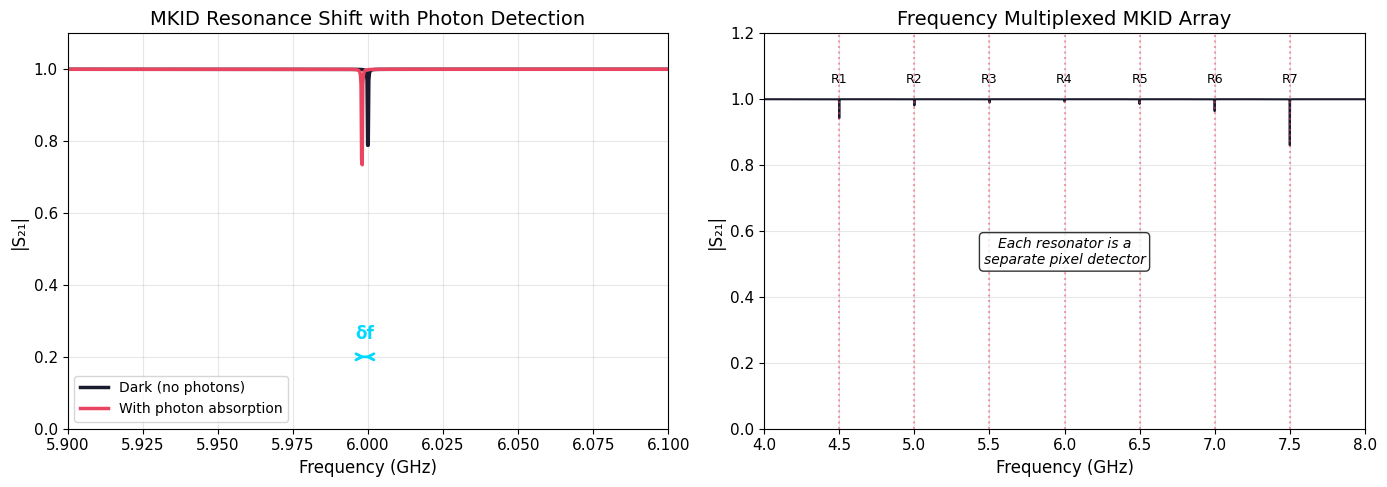

MKID Key Specifications:
  • Frequency resolution: δf/f ~ 10⁻⁶
  • Multiplexing: >1000 resonators per feedline
  • NEP: ~10⁻¹⁹ W/√Hz achievable
  • Operating temperature: 100-300 mK


In [13]:
# MKID principle
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Resonance shift with photon absorption
ax1 = axes[0]
f = np.linspace(5.9, 6.1, 1000)  # GHz

def lorentzian(f, f0, Q, depth):
    return 1 - depth / (1 + 4*Q**2 * ((f - f0)/f0)**2)

Q = 50000
f0_dark = 6.0
depth = 0.8

# Dark state
S21_dark = lorentzian(f, f0_dark, Q, depth)
ax1.plot(f, S21_dark, linewidth=2.5, color=COLORS['primary'], label='Dark (no photons)')

# With photon absorption - frequency shifts and Q decreases
f0_photon = 5.998  # Small shift
Q_photon = 40000
S21_photon = lorentzian(f, f0_photon, Q_photon, depth * 0.9)
ax1.plot(f, S21_photon, linewidth=2.5, color=COLORS['accent1'], label='With photon absorption')

# Mark the shifts
ax1.annotate('', xy=(f0_photon, 0.2), xytext=(f0_dark, 0.2),
             arrowprops=dict(arrowstyle='<->', color=COLORS['highlight'], lw=2))
ax1.text((f0_dark + f0_photon)/2, 0.25, 'δf', fontsize=12, ha='center', 
         color=COLORS['highlight'], fontweight='bold')

ax1.set_xlabel('Frequency (GHz)')
ax1.set_ylabel('|S₂₁|')
ax1.set_title('MKID Resonance Shift with Photon Detection')
ax1.legend()
ax1.set_xlim(5.9, 6.1)
ax1.set_ylim(0, 1.1)

# Right: Multiplexing concept
ax2 = axes[1]
f_wide = np.linspace(4, 8, 2000)

# Multiple resonators at different frequencies
resonator_freqs = [4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5]
S21_total = np.ones_like(f_wide)

for i, f0 in enumerate(resonator_freqs):
    S21_total *= lorentzian(f_wide, f0, 30000, 0.7)

ax2.plot(f_wide, S21_total, linewidth=1.5, color=COLORS['primary'])

# Color the resonances
for i, f0 in enumerate(resonator_freqs):
    ax2.axvline(x=f0, color=COLORS['accent1'], linestyle=':', alpha=0.5)
    ax2.text(f0, 1.05, f'R{i+1}', ha='center', fontsize=9)

ax2.set_xlabel('Frequency (GHz)')
ax2.set_ylabel('|S₂₁|')
ax2.set_title('Frequency Multiplexed MKID Array')
ax2.set_xlim(4, 8)
ax2.set_ylim(0, 1.2)

# Annotation
ax2.text(6, 0.5, 'Each resonator is a\nseparate pixel detector', 
         ha='center', fontsize=10, style='italic',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("MKID Key Specifications:")
print("  • Frequency resolution: δf/f ~ 10⁻⁶")
print("  • Multiplexing: >1000 resonators per feedline")
print("  • NEP: ~10⁻¹⁹ W/√Hz achievable")
print("  • Operating temperature: 100-300 mK")

---
<a id="7-photon-detectors"></a>
# 7. Superconducting Photon Detectors
---

Superconducting detectors offer unparalleled sensitivity for photon detection from X-rays to infrared.

## Detector Types Overview

| Detector | Principle | Wavelength Range | Key Metrics |
|----------|-----------|------------------|-------------|
| **SNSPD** | Nanowire hotspot | UV to mid-IR | >90% efficiency, <50 ps jitter |
| **TES** | Transition edge | X-ray to far-IR | Excellent energy resolution |
| **STJ** | Tunneling current | X-ray to optical | Spectral resolution |
| **MKID** | Kinetic inductance | mm-wave to optical | Large arrays |

## SNSPD: Superconducting Nanowire Single Photon Detector

The SNSPD is the highest-performance single-photon detector for telecom wavelengths.

### Operating Principle

1. **Nanowire** (NbN/NbTiN, ~5 nm thick, ~100 nm wide) biased just below I_c
2. **Photon absorption** creates hotspot, locally suppressing superconductivity
3. **Current crowding** around hotspot exceeds local I_c
4. **Resistive region** forms and expands
5. **Voltage pulse** detected (~mV, ~1 ns rise time)
6. **Recovery** as Joule heat dissipates and superconductivity returns

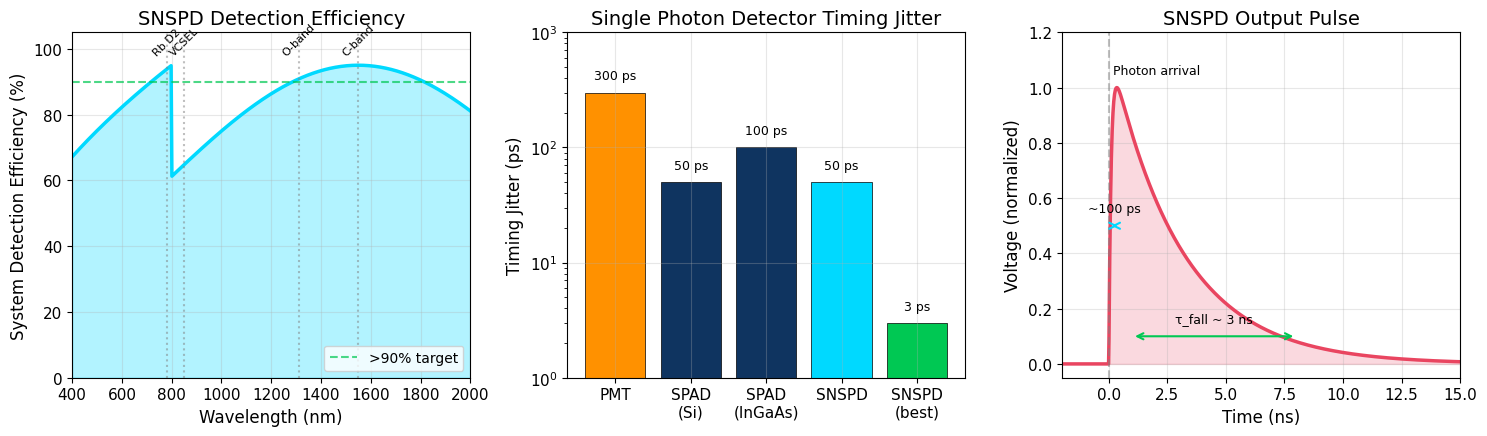

In [14]:
# SNSPD detection mechanism
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Left: Detection efficiency vs wavelength
ax1 = axes[0]
wavelength = np.linspace(400, 2000, 500)  # nm

# Detection efficiency model (simplified)
# Peaks around 1550 nm for optimized devices
def detection_efficiency(wl, wl_opt=1550, width=800):
    # Absorption-limited at short wavelengths, gap-limited at long
    eff = 0.95 * np.exp(-0.5 * ((wl - wl_opt) / width)**2)
    eff[wl < 800] = 0.95 * (wl[wl < 800] / 800)**0.5  # UV roll-off
    return np.minimum(eff, 0.95)

eff = detection_efficiency(wavelength)
ax1.fill_between(wavelength, 0, eff*100, alpha=0.3, color=COLORS['highlight'])
ax1.plot(wavelength, eff*100, linewidth=2.5, color=COLORS['highlight'])

# Mark key wavelengths
key_wavelengths = [(780, 'Rb D2'), (850, 'VCSEL'), (1310, 'O-band'), (1550, 'C-band')]
for wl, name in key_wavelengths:
    ax1.axvline(x=wl, color='gray', linestyle=':', alpha=0.5)
    ax1.text(wl, 98, name, ha='center', fontsize=8, rotation=45)

ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('System Detection Efficiency (%)')
ax1.set_title('SNSPD Detection Efficiency')
ax1.set_xlim(400, 2000)
ax1.set_ylim(0, 105)
ax1.axhline(y=90, color=COLORS['success'], linestyle='--', alpha=0.7, label='>90% target')
ax1.legend()

# Middle: Timing jitter comparison
ax2 = axes[1]
detectors = ['PMT', 'SPAD\n(Si)', 'SPAD\n(InGaAs)', 'SNSPD', 'SNSPD\n(best)']
jitter = [300, 50, 100, 50, 3]  # ps
colors = [COLORS['warning'], COLORS['accent2'], COLORS['accent2'], 
          COLORS['highlight'], COLORS['success']]

bars = ax2.bar(detectors, jitter, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_ylabel('Timing Jitter (ps)')
ax2.set_title('Single Photon Detector Timing Jitter')
ax2.set_yscale('log')
ax2.set_ylim(1, 1000)

# Add value labels
for bar, j in zip(bars, jitter):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.3, 
             f'{j} ps', ha='center', fontsize=9)

# Right: SNSPD pulse shape
ax3 = axes[2]
t = np.linspace(-2, 15, 1000)  # ns

# Simplified pulse model
tau_rise = 0.1  # ns
tau_fall = 3    # ns

pulse = np.zeros_like(t)
pulse[t >= 0] = (1 - np.exp(-t[t >= 0]/tau_rise)) * np.exp(-t[t >= 0]/tau_fall)
pulse = pulse / np.max(pulse)  # Normalize

ax3.plot(t, pulse, linewidth=2.5, color=COLORS['accent1'])
ax3.fill_between(t, 0, pulse, alpha=0.2, color=COLORS['accent1'])

# Mark timing features
ax3.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax3.text(0.2, 1.05, 'Photon arrival', fontsize=9)

ax3.annotate('', xy=(0.5, 0.5), xytext=(0, 0.5),
             arrowprops=dict(arrowstyle='<->', color=COLORS['highlight'], lw=1.5))
ax3.text(0.25, 0.55, f'~{tau_rise*1000:.0f} ps', fontsize=9, ha='center')

ax3.annotate('', xy=(8, 0.1), xytext=(1, 0.1),
             arrowprops=dict(arrowstyle='<->', color=COLORS['success'], lw=1.5))
ax3.text(4.5, 0.15, f'τ_fall ~ {tau_fall} ns', fontsize=9, ha='center')

ax3.set_xlabel('Time (ns)')
ax3.set_ylabel('Voltage (normalized)')
ax3.set_title('SNSPD Output Pulse')
ax3.set_xlim(-2, 15)
ax3.set_ylim(-0.05, 1.2)

plt.tight_layout()
plt.show()

### SNSPD Applications

| Application | Requirements Met by SNSPD |
|-------------|---------------------------|
| **Quantum Key Distribution (QKD)** | High efficiency, low dark counts, telecom wavelength |
| **LIDAR/Ranging** | Picosecond jitter, high count rates |
| **Deep-space optical comm** | High sensitivity, low noise |
| **Quantum computing readout** | Fast, efficient single-photon detection |
| **Fluorescence lifetime imaging** | Timing resolution, visible wavelengths |

## TES: Transition Edge Sensor

The TES operates at the superconducting transition edge, providing excellent **energy resolution**.

### Operating Principle

1. **Thin film** (Mo/Cu, Ti, W) voltage-biased at transition edge
2. **Steep R(T)** provides strong electrothermal feedback
3. **Photon absorption** raises temperature → resistance change
4. **Current change** measured by SQUID
5. **Self-regulation** returns to operating point

### Energy Resolution

$$\Delta E_{FWHM} \approx 2.35 \sqrt{4 k_B T^2 C / \alpha}$$

where α = T/R × dR/dT is the transition sharpness.

In [15]:
# TES operating principle
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), constrained_layout=True)

# Left: R(T) curve and operating point
ax1 = axes[0]
T = np.linspace(90, 110, 500)  # mK
T_c = 100  # mK
delta_T = 2  # Transition width in mK

# Fermi function for transition
R_n = 100  # mΩ normal state
R = R_n / (1 + np.exp(-(T - T_c) / delta_T))

ax1.plot(T, R*1000, linewidth=2.5, color=COLORS['accent1'])
ax1.fill_between(T, 0, R*1000, alpha=0.2, color=COLORS['accent1'])

# Operating point
T_op = T_c
R_op = R_n / 2
ax1.plot(T_op, R_op*1000, 'o', markersize=12, color=COLORS['success'], zorder=5)
ax1.text(T_op+2, R_op*1000, 'Operating\npoint', fontsize=10, color=COLORS['success'])

# Show α = steepness
ax1.annotate('', xy=(T_c+1, 70), xytext=(T_c-1, 30),
             arrowprops=dict(arrowstyle='->', color=COLORS['highlight'], lw=2))
ax1.text(T_c-3, 45, 'α = T/R × dR/dT\n(~100-1000)', fontsize=9, color=COLORS['highlight'])

ax1.set_xlabel('Temperature (mK)')
ax1.set_ylabel('Resistance (mΩ)')
ax1.set_title('TES Resistance vs Temperature')
ax1.set_xlim(90, 110)
ax1.set_ylim(0, 120)

# Middle: Energy resolution comparison
ax2 = axes[1]
detectors = ['Si detector', 'Ge detector', 'Scintillator', 'TES\n(X-ray)', 'TES\n(optical)']
resolution = [150, 3000, 50000, 2, 0.1]  # eV at 6 keV (or equivalent)
colors = [COLORS['accent2'], COLORS['accent2'], COLORS['warning'], 
          COLORS['highlight'], COLORS['success']]

bars = ax2.bar(detectors, resolution, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_ylabel('Energy Resolution (eV)')
ax2.set_title('X-ray Detector Energy Resolution\n(at ~6 keV)')
ax2.set_yscale('log')
ax2.set_ylim(0.05, 100000)

# Add value labels
for bar, res in zip(bars, resolution):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.5, 
             f'{res} eV', ha='center', fontsize=9)

# Right: TES pulse and readout
ax3 = axes[2]
t = np.linspace(-0.5, 3, 1000)  # ms

# TES pulse - exponential rise and fall
tau_rise = 0.05  # ms
tau_fall = 0.5   # ms (ETF limited)

pulse = np.zeros_like(t)
pulse[t >= 0] = (1 - np.exp(-t[t >= 0]/tau_rise)) * np.exp(-t[t >= 0]/tau_fall)
pulse = pulse / np.max(pulse)

# Different energy photons
energies = [1.0, 0.6, 0.3]
for E, color in zip(energies, [COLORS['accent1'], COLORS['accent2'], COLORS['highlight']]):
    ax3.plot(t, E * pulse, linewidth=2, color=color, label=f'{E:.1f} keV')

ax3.set_xlabel('Time (ms)')
ax3.set_ylabel('Signal (normalized)')
ax3.set_title('TES Pulses for Different Photon Energies')
ax3.legend()
ax3.set_xlim(-0.5, 3)
ax3.set_ylim(-0.05, 1.1)

# Note about energy resolution
ax3.text(1.5, 0.7, 'Pulse height ∝ Energy', fontsize=10, style='italic',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

print("TES Key Specifications:")
print("  • Energy resolution: ~2 eV at 6 keV (X-ray)")
print("  • Operating temperature: 50-100 mK typical")
print("  • Transition sharpness α: 100-1000")
print("  • Applications: X-ray spectroscopy, CMB, dark matter")

/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


TES Key Specifications:
  • Energy resolution: ~2 eV at 6 keV (X-ray)
  • Operating temperature: 50-100 mK typical
  • Transition sharpness α: 100-1000
  • Applications: X-ray spectroscopy, CMB, dark matter


## STJ: Superconducting Tunnel Junction

STJs detect photons through creation of quasiparticles, which modify the tunneling current.

### Operating Principle

1. **SIS junction** biased at small voltage (V < 2Δ/e)
2. **Photon absorption** creates quasiparticles (N ≈ E_photon / 1.7Δ)
3. **Quasiparticles tunnel** through barrier
4. **Current pulse** proportional to photon energy

| Parameter | Typical Value |
|-----------|---------------|
| Materials | Nb/Al-AlOx/Nb, Ta |
| Operating T | 0.3-0.5 K |
| Energy resolution | ~10 eV at 6 keV |
| Wavelength range | X-ray to optical |

## Detector Performance Comparison

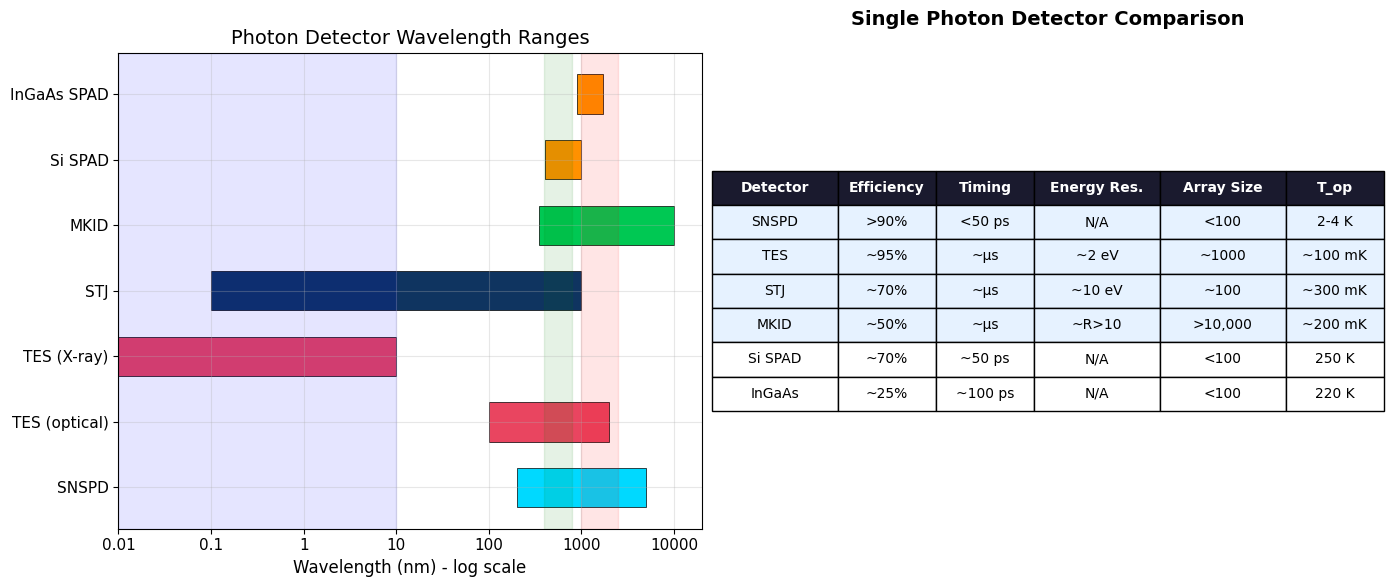

In [16]:
# Comprehensive detector comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Operating wavelength ranges
ax1 = axes[0]

detectors_range = {
    'SNSPD': (200, 5000),      # nm
    'TES (optical)': (100, 2000),
    'TES (X-ray)': (0.01, 10),  # nm (X-ray)
    'STJ': (0.1, 1000),
    'MKID': (350, 10000),
    'Si SPAD': (400, 1000),
    'InGaAs SPAD': (900, 1700)
}

y_pos = np.arange(len(detectors_range))
colors = [COLORS['highlight'], COLORS['accent1'], COLORS['accent1'], 
          COLORS['accent2'], COLORS['success'], COLORS['warning'], COLORS['warning']]

for i, (det, (wl_min, wl_max)) in enumerate(detectors_range.items()):
    ax1.barh(i, np.log10(wl_max) - np.log10(wl_min), left=np.log10(wl_min), 
             height=0.6, color=colors[i], edgecolor='black', linewidth=0.5)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(detectors_range.keys())
ax1.set_xlabel('Wavelength (nm) - log scale')
ax1.set_title('Photon Detector Wavelength Ranges')

# Custom x-axis labels
ax1.set_xticks([-2, -1, 0, 1, 2, 3, 4])
ax1.set_xticklabels(['0.01', '0.1', '1', '10', '100', '1000', '10000'])

# Mark key regions
ax1.axvspan(-2, 1, alpha=0.1, color='blue', label='X-ray')
ax1.axvspan(2.6, 2.9, alpha=0.1, color='green', label='Visible')
ax1.axvspan(3.0, 3.4, alpha=0.1, color='red', label='Telecom')

# Right: Performance summary table as visual
ax2 = axes[1]
ax2.axis('off')

# Create table data
table_data = [
    ['Detector', 'Efficiency', 'Timing', 'Energy Res.', 'Array Size', 'T_op'],
    ['SNSPD', '>90%', '<50 ps', 'N/A', '<100', '2-4 K'],
    ['TES', '~95%', '~μs', '~2 eV', '~1000', '~100 mK'],
    ['STJ', '~70%', '~μs', '~10 eV', '~100', '~300 mK'],
    ['MKID', '~50%', '~μs', '~R>10', '>10,000', '~200 mK'],
    ['Si SPAD', '~70%', '~50 ps', 'N/A', '<100', '250 K'],
    ['InGaAs', '~25%', '~100 ps', 'N/A', '<100', '220 K']
]

# Draw table
table = ax2.table(cellText=table_data, loc='center', cellLoc='center',
                  colWidths=[0.18, 0.14, 0.14, 0.18, 0.18, 0.14])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)

# Style header row
for j in range(6):
    table[(0, j)].set_facecolor(COLORS['primary'])
    table[(0, j)].set_text_props(color='white', fontweight='bold')

# Highlight superconducting detectors
for i in range(1, 5):
    for j in range(6):
        table[(i, j)].set_facecolor('#e6f2ff')

ax2.set_title('Single Photon Detector Comparison', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

---
## Summary

**Device Categories and Capabilities:**
- **SQUIDs** (DC/RF magnetometers): 10⁻¹⁵ T/√Hz sensitivity
- **Parametric Amplifiers** (JPA, TWPA): Quantum-limited noise (~0.5 photons)
- **Kinetic Inductance** (MKIDs): Large multiplexed arrays
- **Photon Detectors** (SNSPD, TES, STJ): >90% efficiency, ps timing, eV resolution

### Key Takeaways

- **SQUIDs** remain the gold standard for ultra-sensitive magnetometry
- **Parametric amplifiers** are essential for quantum computing readout
- **Kinetic inductance** enables compact, high-inductance structures
- **Superconducting detectors** outperform semiconductors in sensitivity